In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti
import time as T

cd = "CDK183"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.5
const = 2.5e-3 * 2 * np.pi

# symmetrical shape

In [9]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2025-07-18", acquire_time="111344", params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.2, date="2025-07-18", acquire_time="113515", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data3 = dict(amp=0.25, date="2025-07-18", acquire_time="114909", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data4 = dict(amp=0.3, date="2025-07-18", acquire_time="115638", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data5 = dict(amp=0.35, date="2025-07-18", acquire_time="121057", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data6 = dict(amp=0.4, date="2025-07-18", acquire_time="121701", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data7 = dict(amp=0.425, date="2025-07-18", acquire_time="122747", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data8 = dict(amp=0.45, date="2025-07-18", acquire_time="123832", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data9 = dict(amp=0.475, date="2025-07-18", acquire_time="124436", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data10 = dict(amp=0.5, date="2025-07-18", acquire_time="125041", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
)

# Generating Control Pulses

0.1 2025-07-18 111344
0.2 2025-07-18 113515
0.25 2025-07-18 114909
0.3 2025-07-18 115638
0.35 2025-07-18 121057
0.4 2025-07-18 121701
0.425 2025-07-18 122747
0.45 2025-07-18 123832


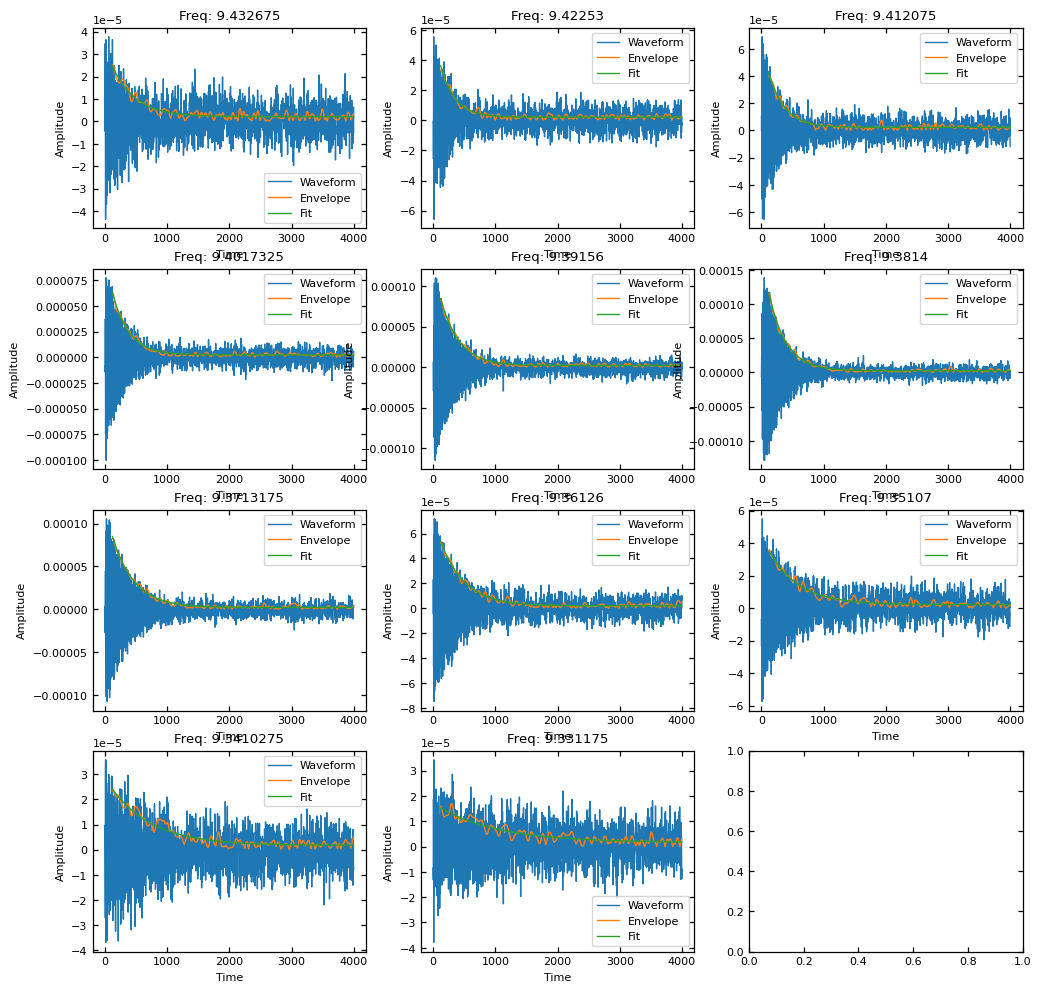

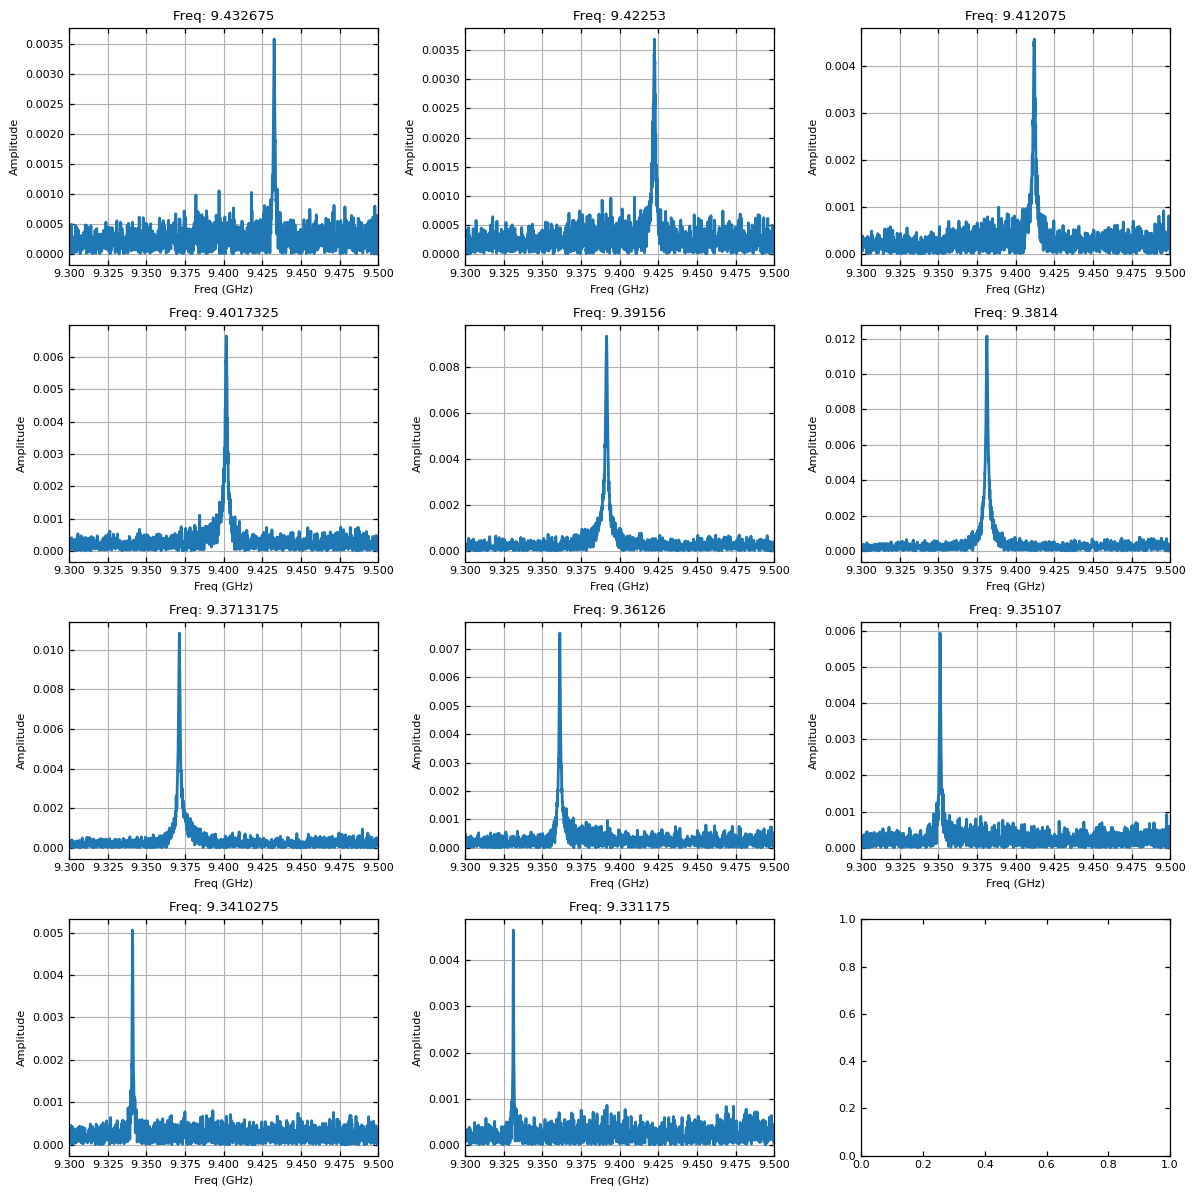

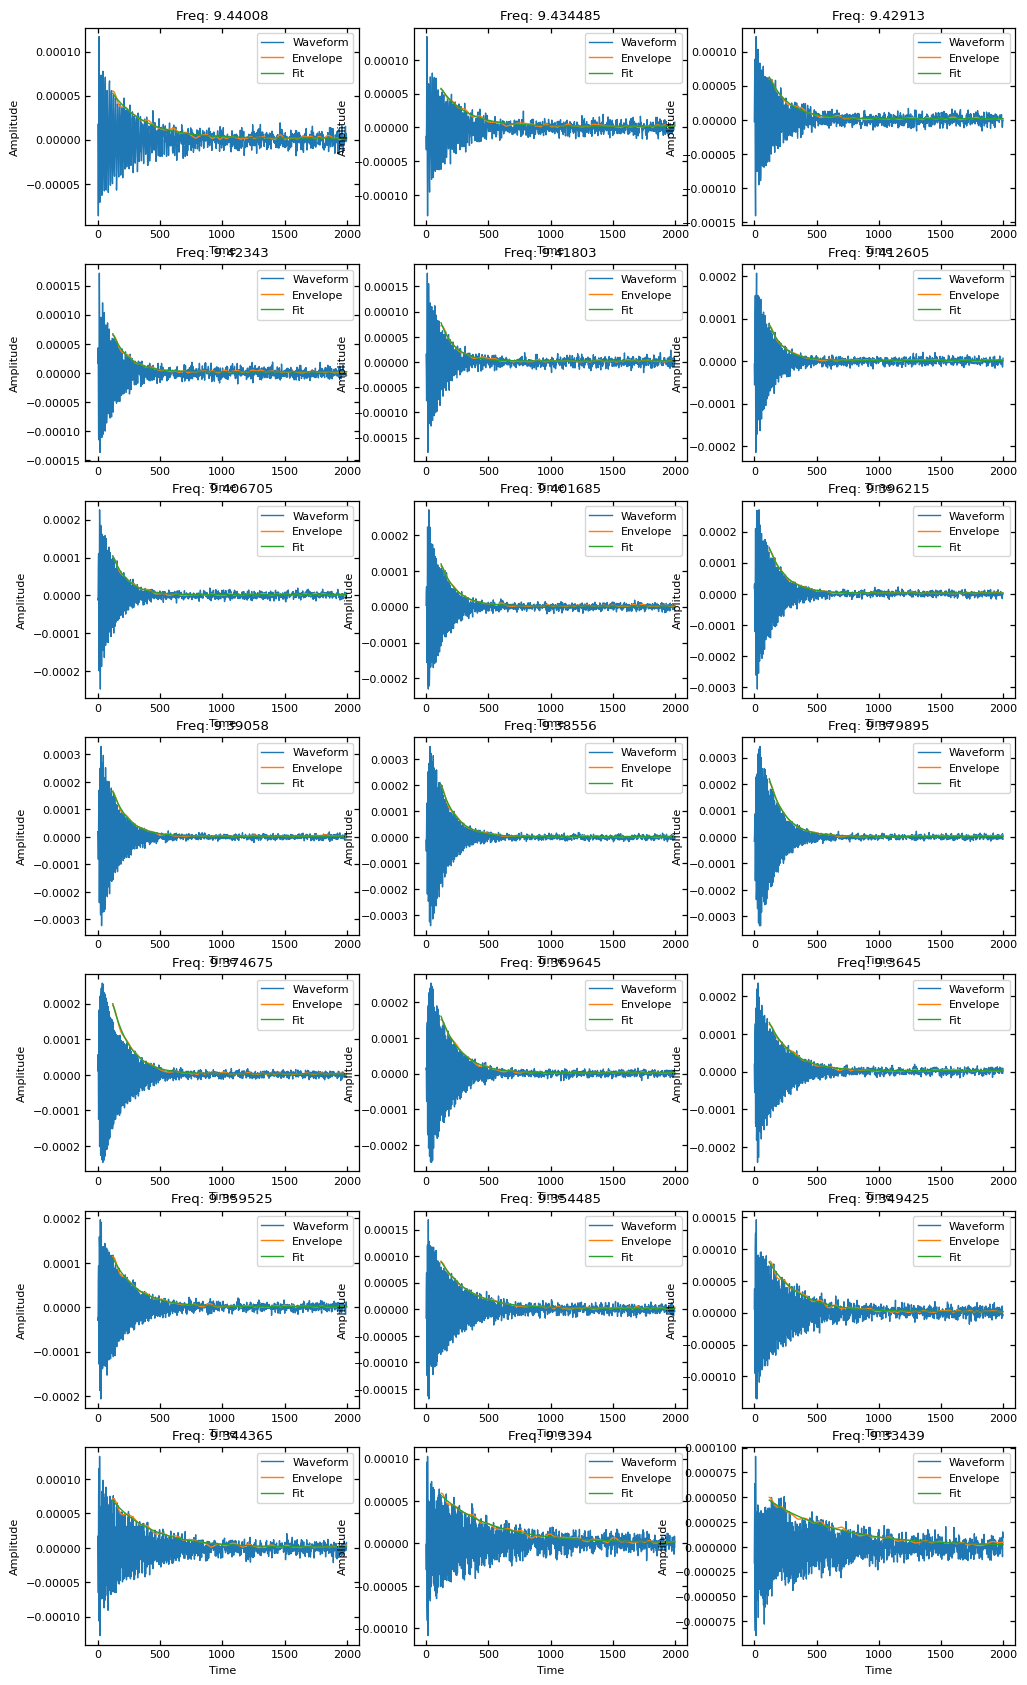

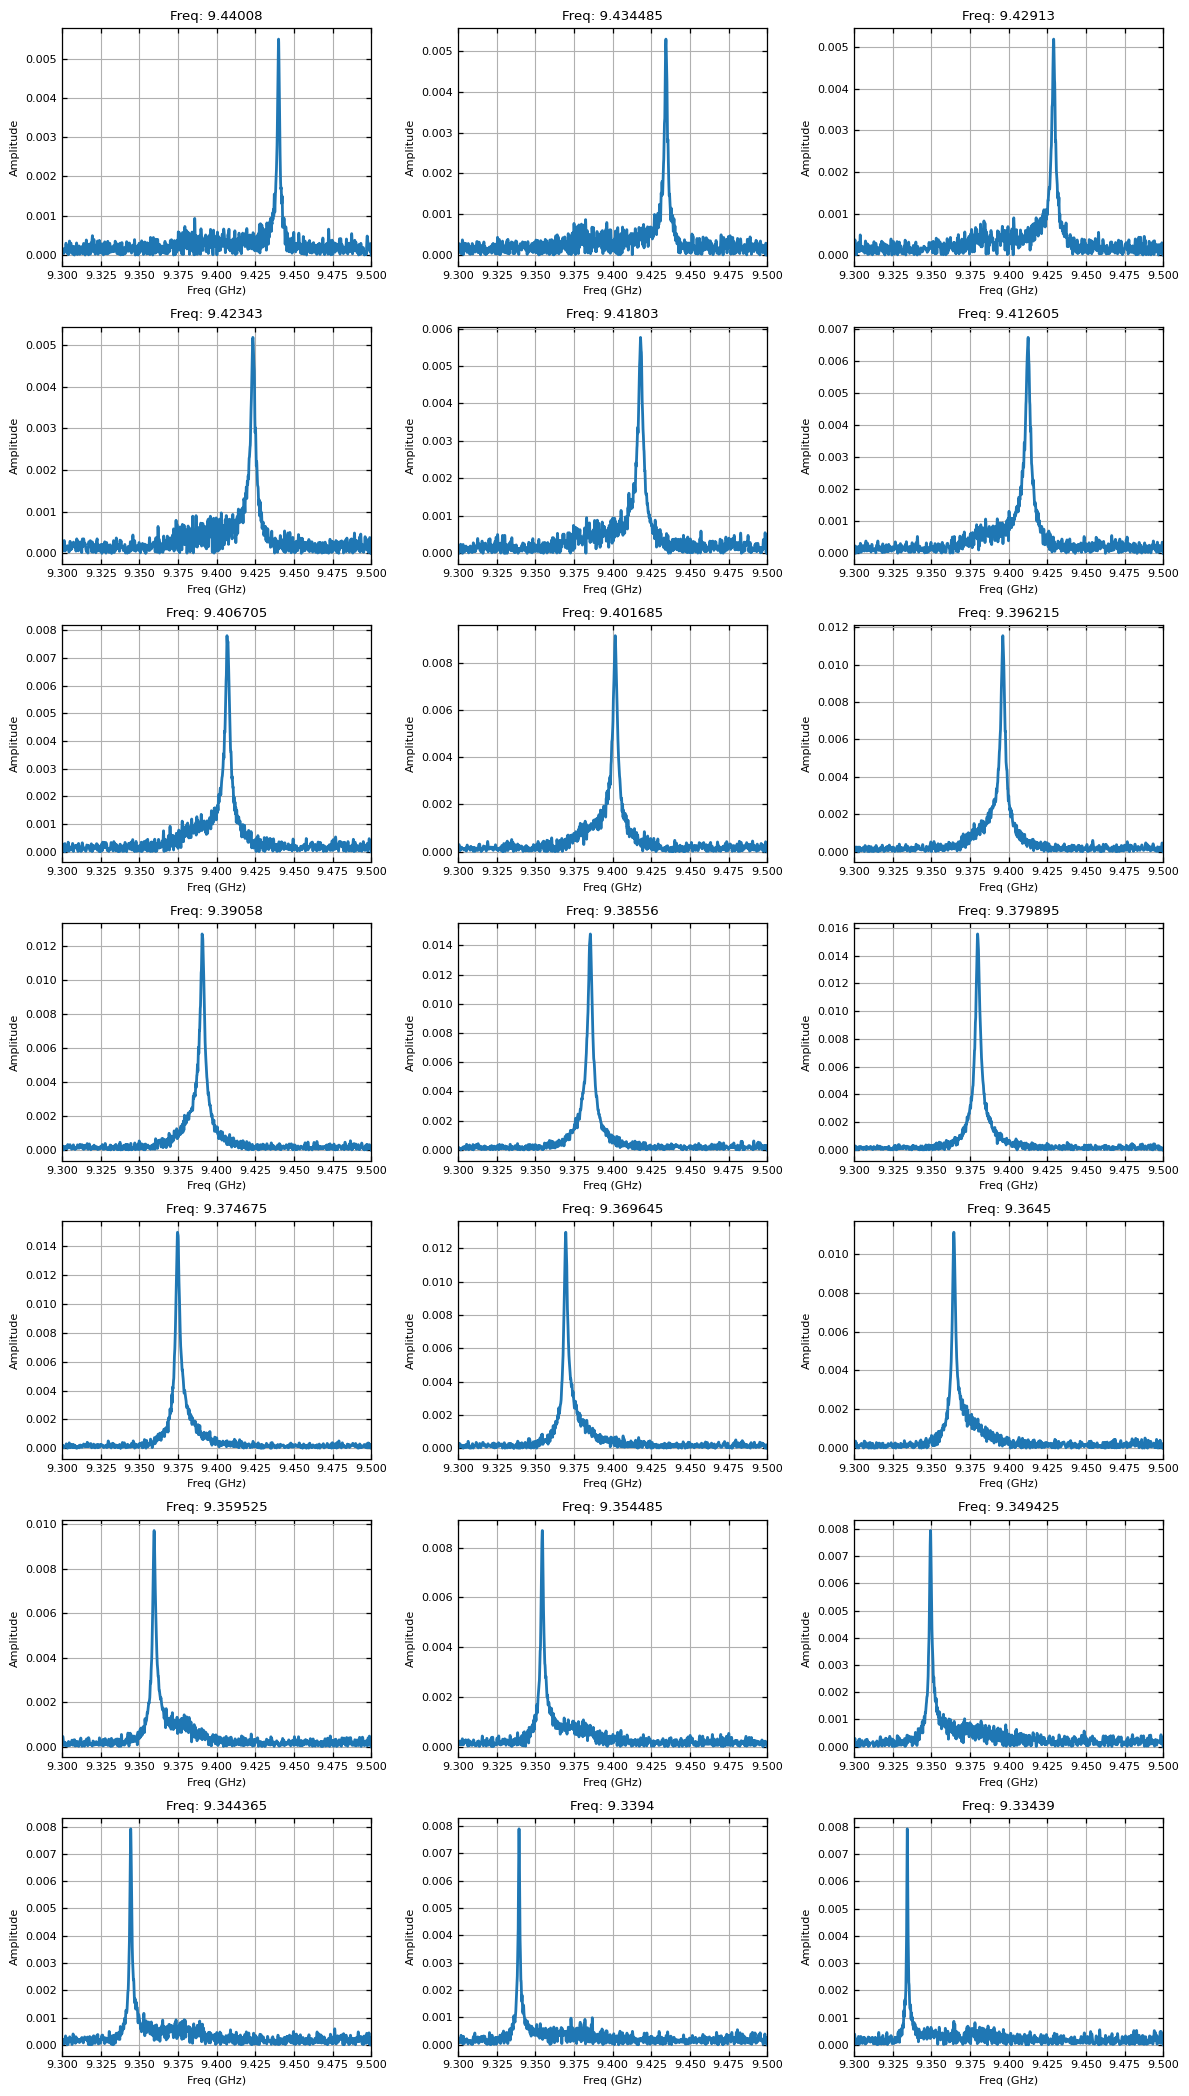

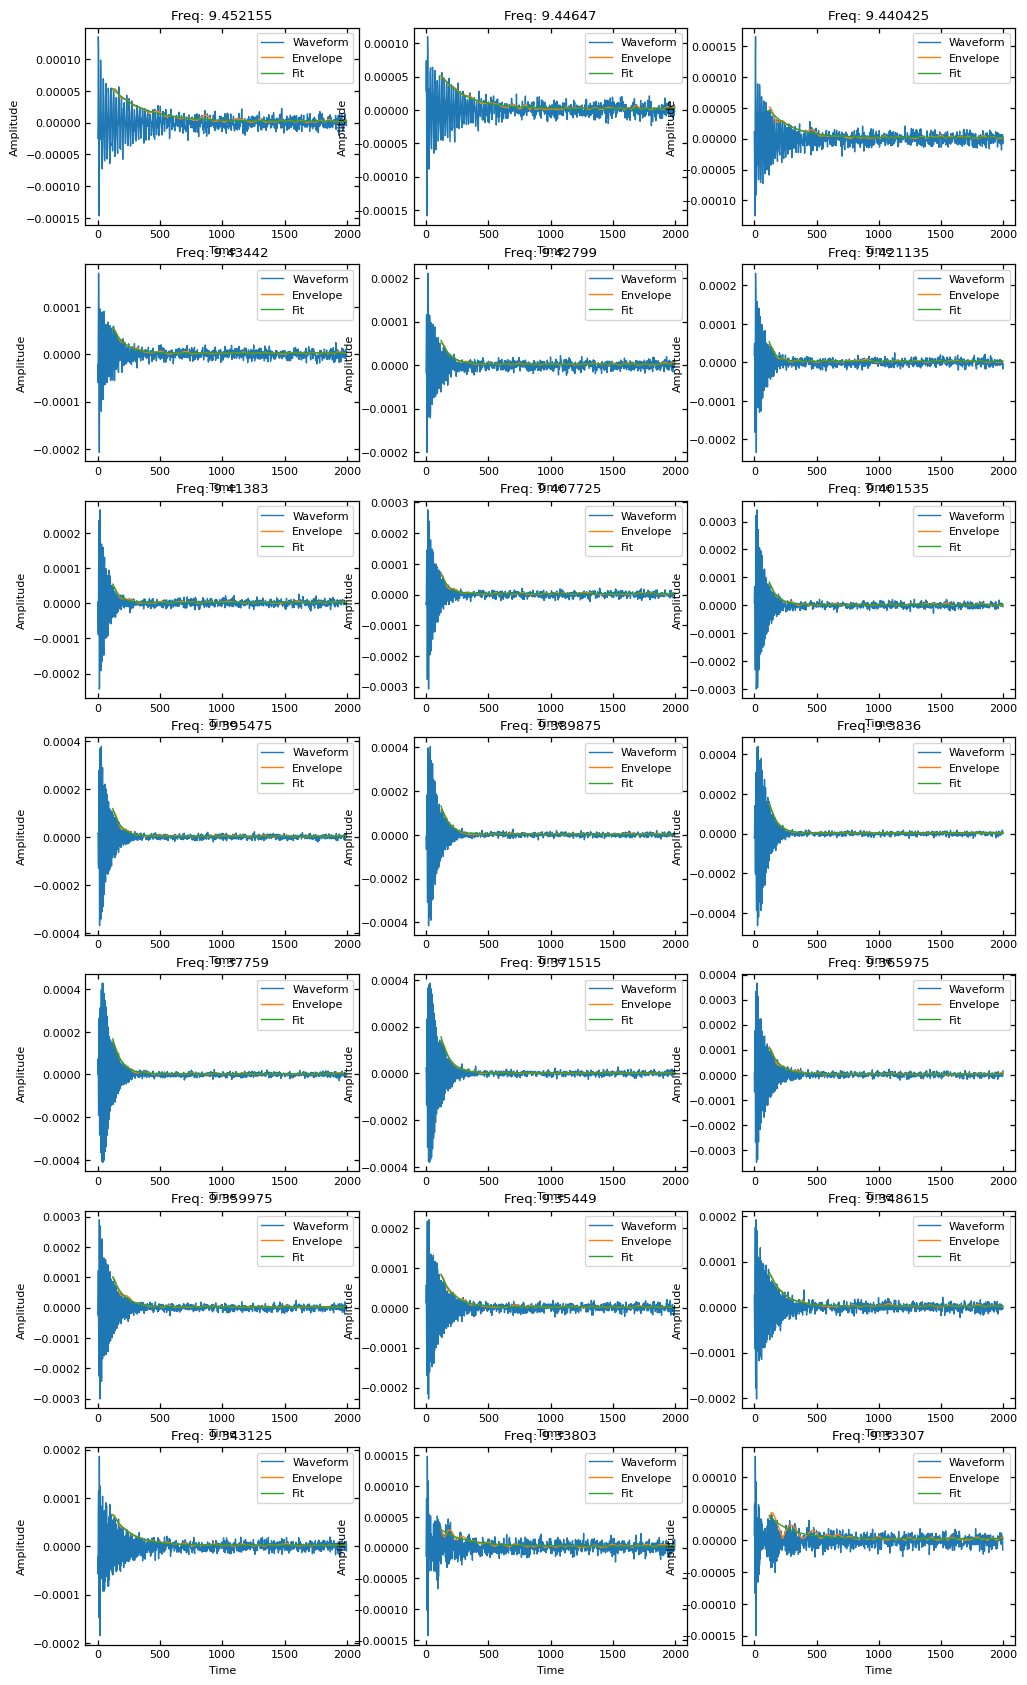

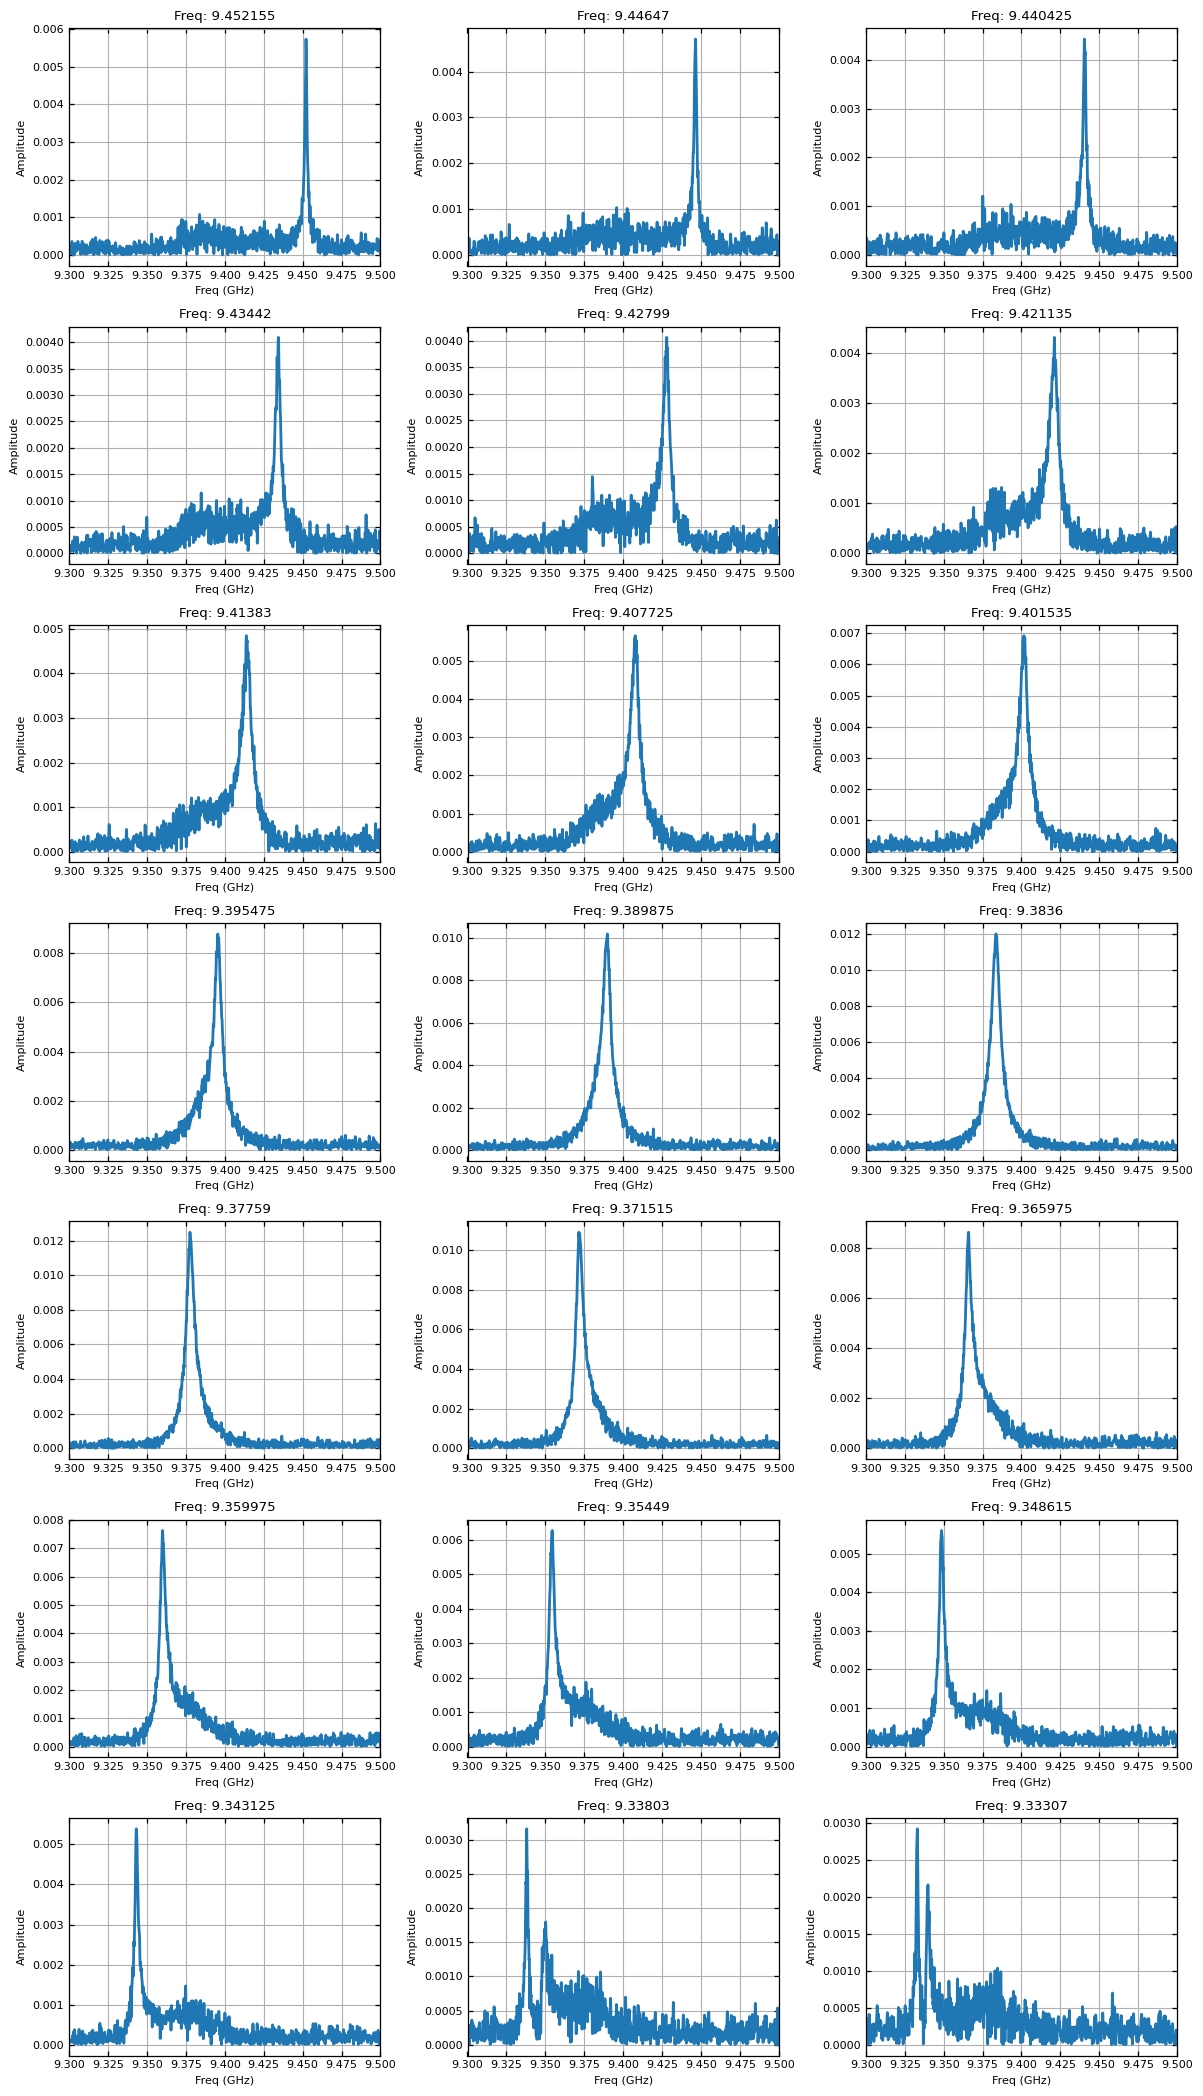

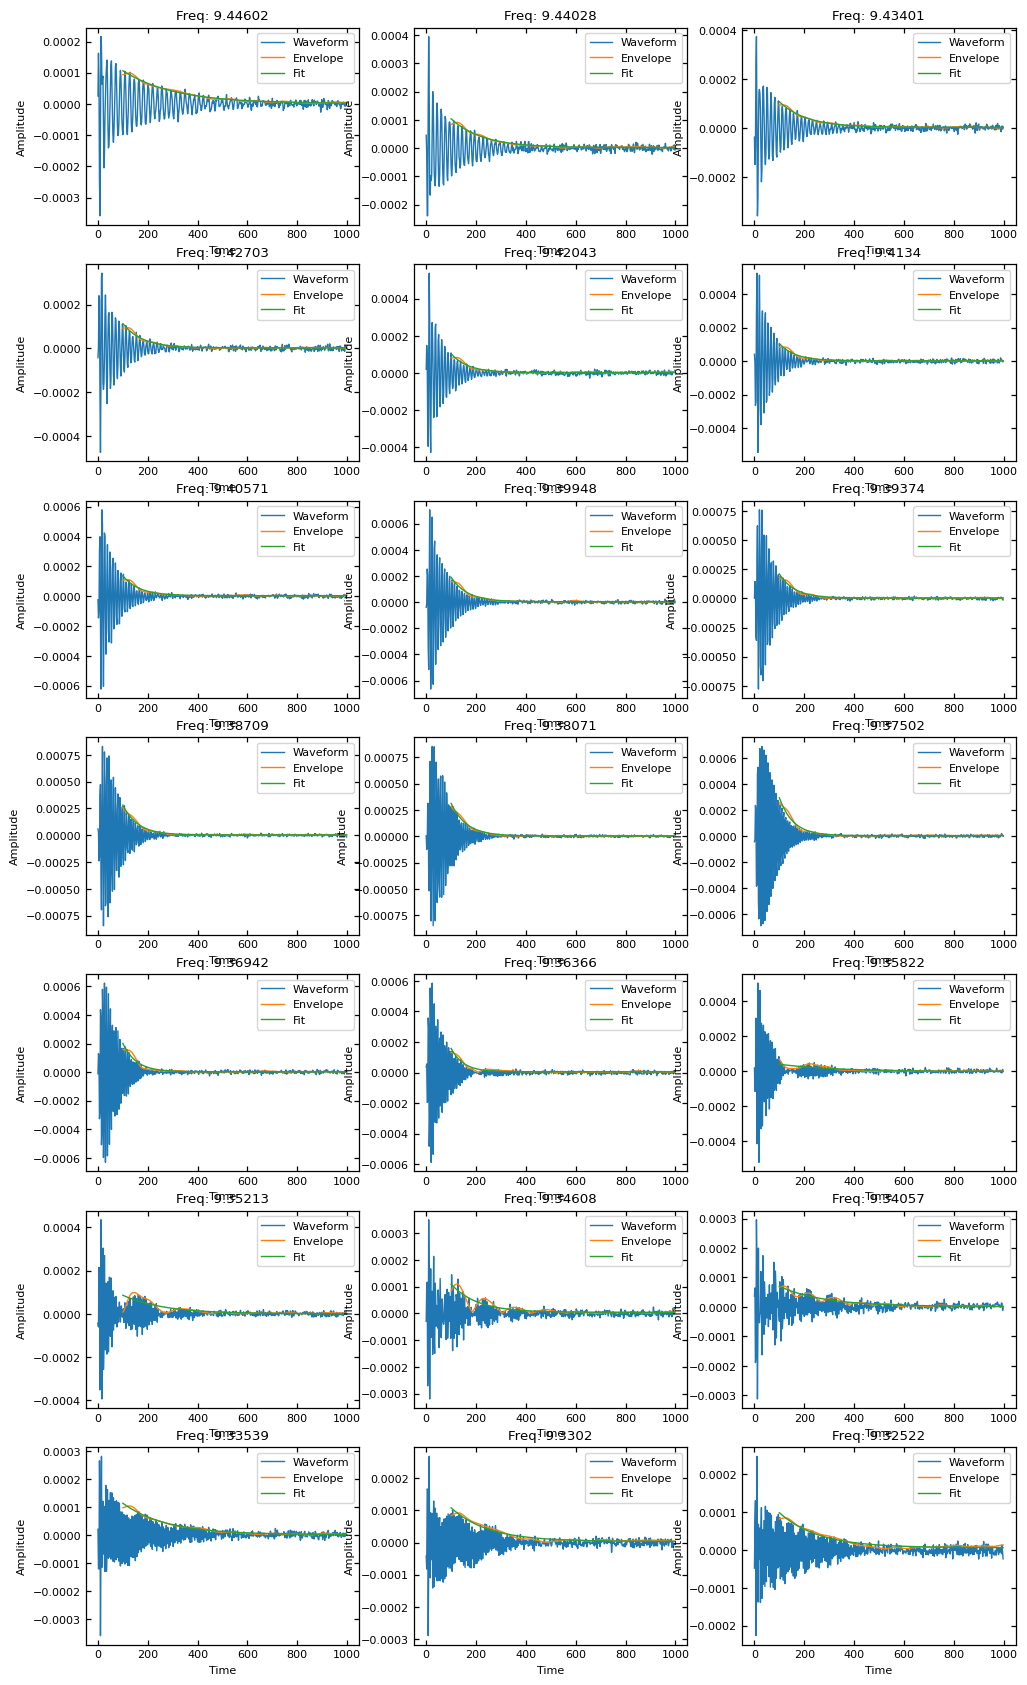

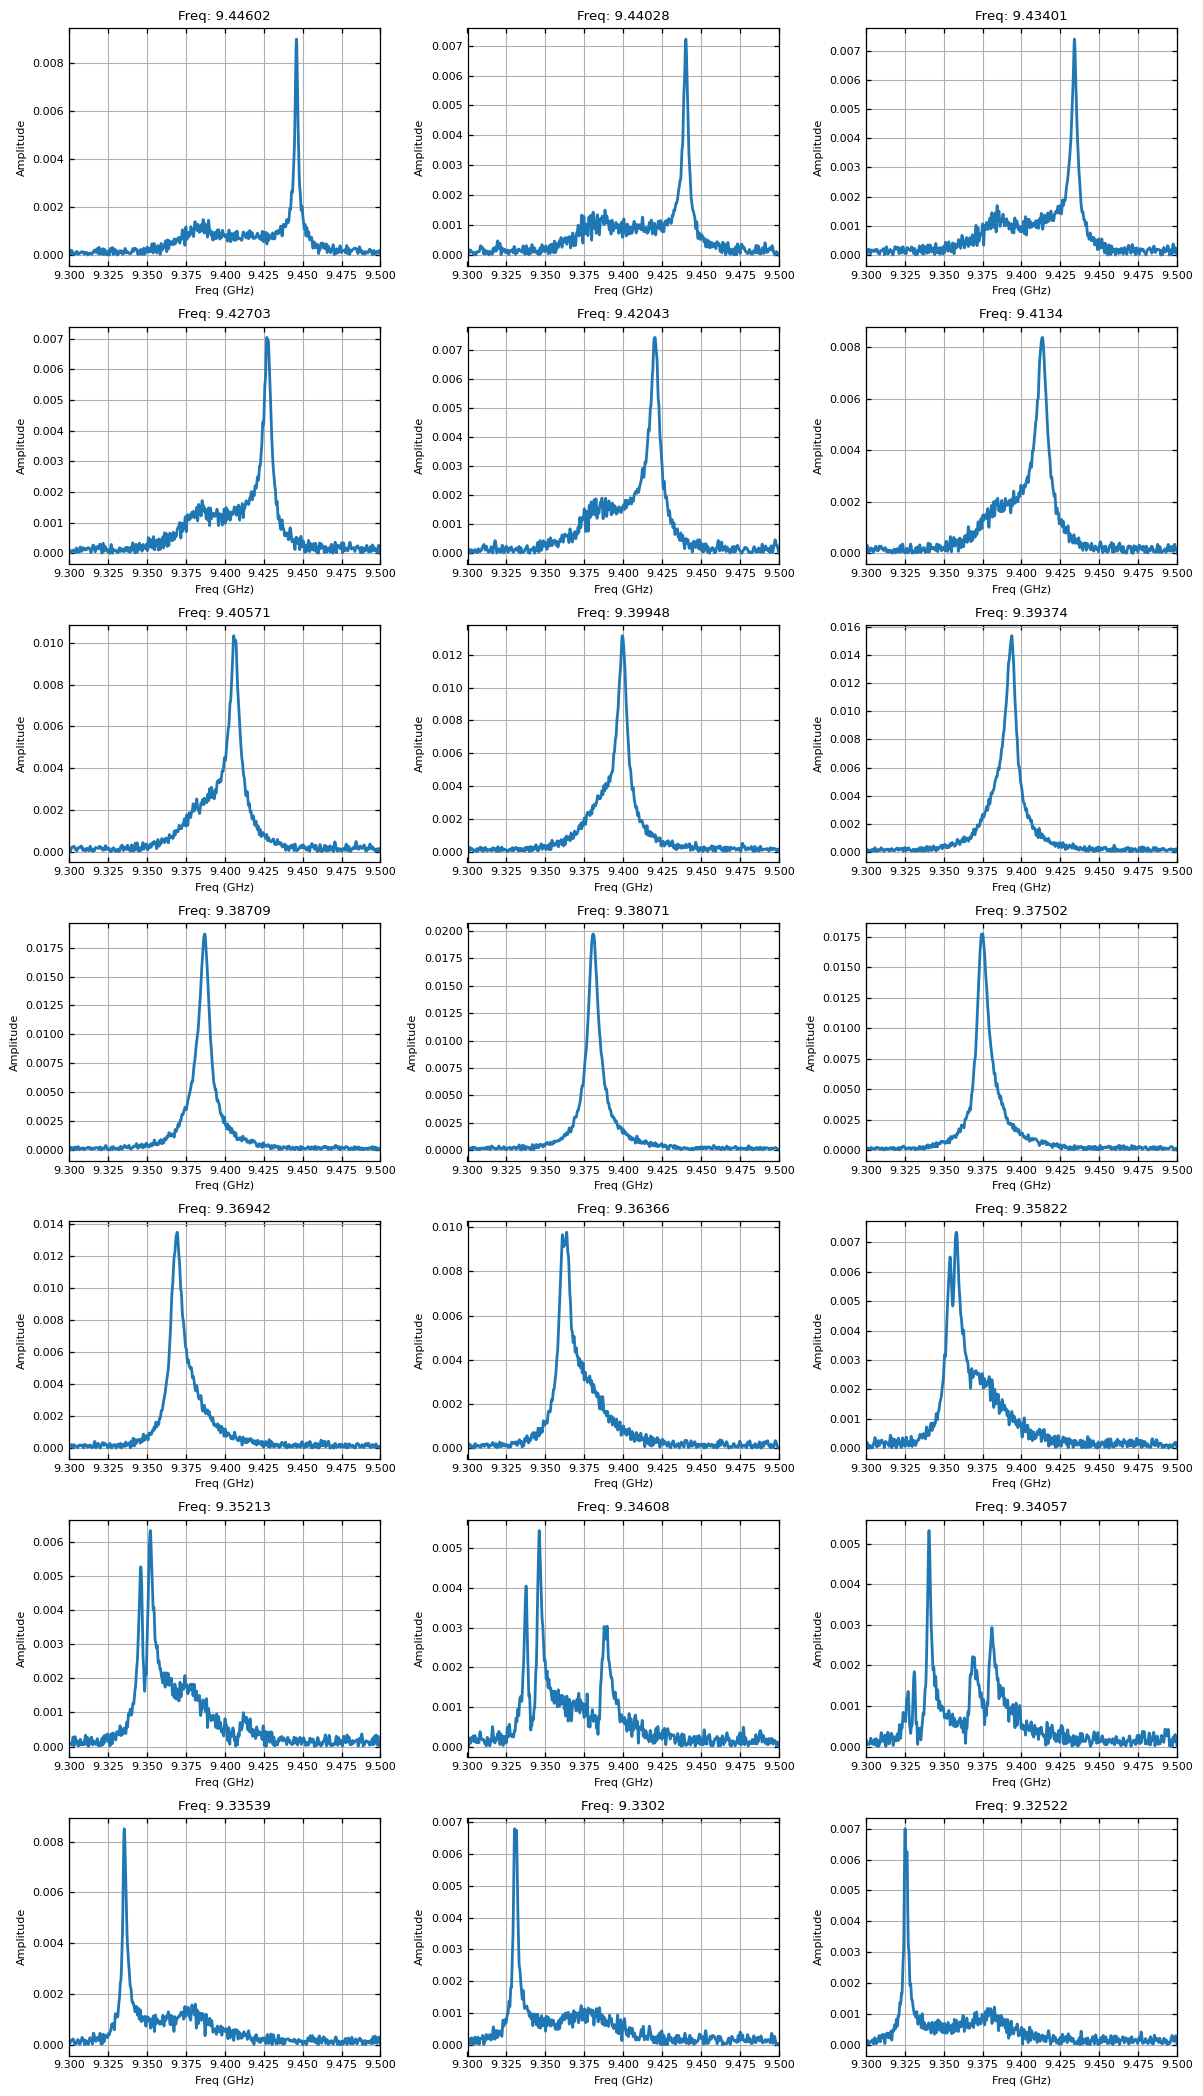

In [10]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

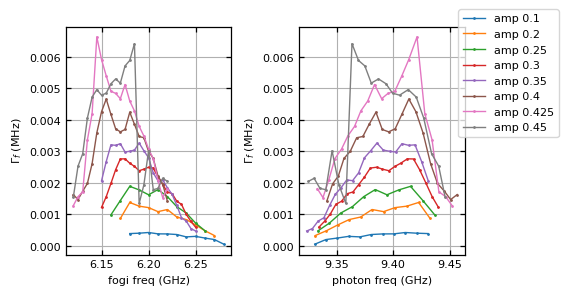

{'a0': 0, 'a2': 0.025037868318827927, 'a4': 7.960980763499492e-10, 'a6': 3.115285807098189e-13, 'a8': 1.092237411626229e-12, 'a10': 2.2511770225719374e-11}


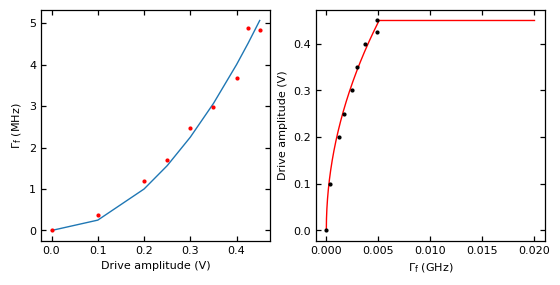

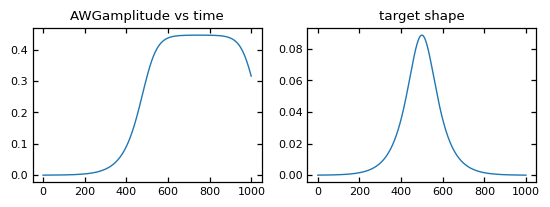

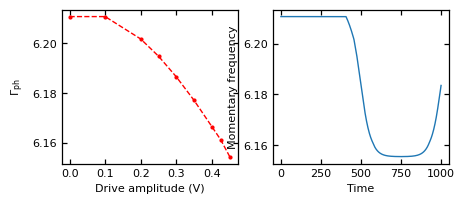

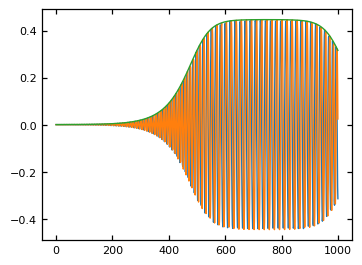

In [11]:
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.4

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(6.1, target_freq, duration, kappa=const*2, form="sech",mode_id=0)[0]

## save

In [6]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
form = "sech"
mode_ids = np.linspace(0, 3, 4)

for mode_id in mode_ids:
    for target_freq in [9.38]:
        control_pulse, control_envelope = dataobj.generate_control_pulse(
           6.1, target_freq, duration, kappa=const*2, form=form, mode_id=int(mode_id), plot=False
        )

        note = f"""
        form : {form}
        mode_id : {mode_id}
        const : {const / 2 / np.pi}
        duration : {duration}
        target frequency : {target_freq} GHz
        """

        data = DataDict(
            time=dict(unit="ns"),
            control_pulse=dict(axes=["time"]),
            control_envelope=dict(axes=["time"])
        )
        data.validate()

        save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
            writer.add_tag(["control_pulse", cd, form])
            writer.save_text("target_shape.md", note)
            writer.add_data(
                time=np.arange(len(control_pulse)),
                control_pulse=control_pulse,
                control_envelope=control_envelope
            )
        T.sleep(1)


{'a0': 0, 'a2': 0.02570787239731498, 'a4': 8.350209412810727e-12, 'a6': 8.085754288345015e-12, 'a8': 1.2884582289984792e-11, 'a10': 0.13286001837494732}
{'a0': 0, 'a2': 0.02570787239731498, 'a4': 8.350209412810727e-12, 'a6': 8.085754288345015e-12, 'a8': 1.2884582289984792e-11, 'a10': 0.13286001837494732}
{'a0': 0, 'a2': 0.02570787239731498, 'a4': 8.350209412810727e-12, 'a6': 8.085754288345015e-12, 'a8': 1.2884582289984792e-11, 'a10': 0.13286001837494732}
{'a0': 0, 'a2': 0.02570787239731498, 'a4': 8.350209412810727e-12, 'a6': 8.085754288345015e-12, 'a8': 1.2884582289984792e-11, 'a10': 0.13286001837494732}


# Photon shaping analysis

In [2]:
from Analysis import SechPhotonAnalysis

phase: -1.3802585166881485
sign: 1.0
phase: -2.556237695241914
sign: -1.0
phase: 2.4246036966173063
sign: 1.0
phase: 1.0135291760618845
sign: -1.0


<Figure size 640x480 with 0 Axes>

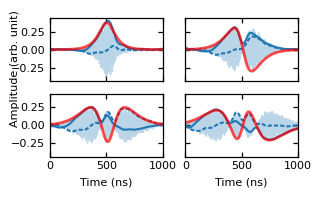

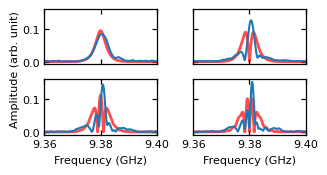

In [3]:
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.5
duration = 1000
passing_band = 0.01
const = 2.5e-3*2*np.pi
result_dict = {
    "data_sech_0": dict(target_freq=9.38, date="2025-07-18", acquire_time="222752", form="sech", mode_id=0, x0=[2.5e-3, 450]),
    "data_sech_1": dict(target_freq=9.38, date="2025-07-18", acquire_time="222843", form="sech", mode_id=1, x0=[2.5e-3, 450]),
    "data_sech_2": dict(target_freq=9.38, date="2025-07-18", acquire_time="222934", form="sech", mode_id=2, x0=[2.5e-3, 450]),
    "data_sech_3": dict(target_freq=9.38, date="2025-07-18", acquire_time="223024", form="sech", mode_id=3, x0=[2.5e-3, 450]),
}

analyzer = SechPhotonAnalysis(data_path, result_dict, duration, const*2, readout_lo_freq)
analyzer.analyze_waveforms(passing_band)

phase subtraction

sign: 1.0
sign: -1.0
sign: 1.0
sign: -1.0


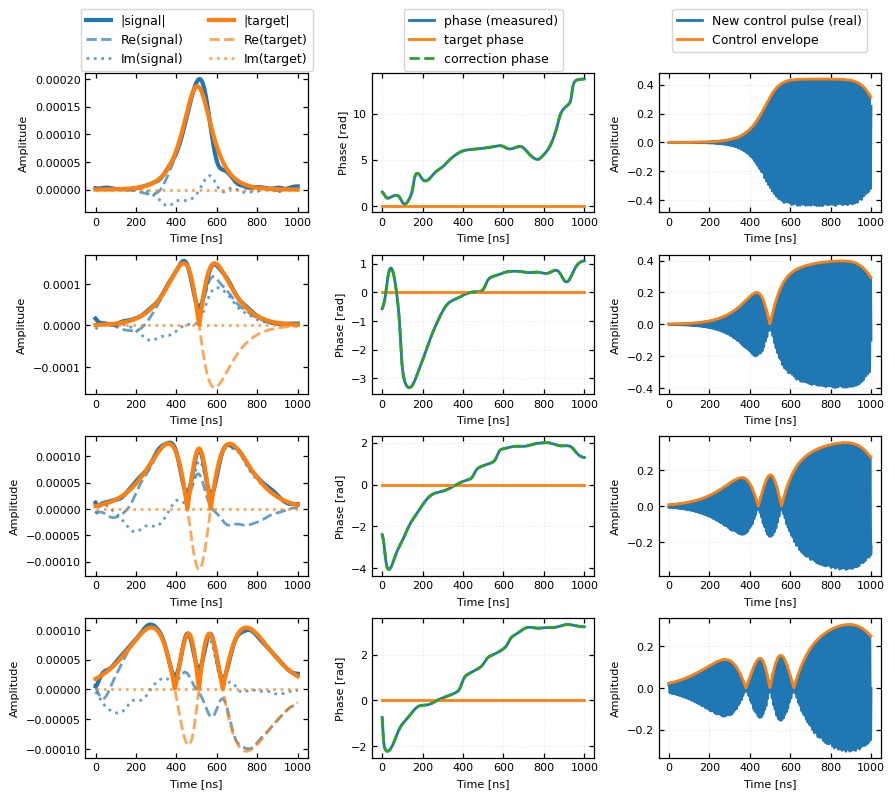

In [4]:
ctrl_pulse_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\"
analyzer.phase_subtraction_and_pulse_flip(ctrl_pulse_path, save=False)

corrected photon shaping

phase: 1.4549095204802427
sign: 1.0
phase: 0.7794916757561564
sign: -1.0
phase: 0.4515207076863856
sign: 1.0
phase: 0.17898909946667538
sign: -1.0


<Figure size 640x480 with 0 Axes>

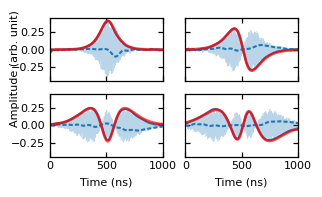

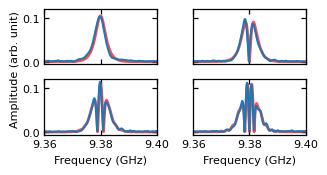

In [5]:
const = 2.5e-3*2*np.pi
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.38, date="2025-07-18", acquire_time="223216", form="sech", mode_id=0, x0=[2.5e-3, 450]),
    "data_sech_1": dict(target_freq=9.38, date="2025-07-18", acquire_time="223306", form="sech", mode_id=1, x0=[2.5e-3, 450]),
    "data_sech_2": dict(target_freq=9.38, date="2025-07-18", acquire_time="223356", form="sech", mode_id=2, x0=[2.5e-3, 450]),
    "data_sech_3": dict(target_freq=9.38, date="2025-07-18", acquire_time="223446", form="sech", mode_id=3, x0=[2.5e-3, 450]),
}

corrected_analyzer = SechPhotonAnalysis(data_path, corrected_result_dict, duration, const*2, readout_lo_freq)
corrected_analyzer.analyze_waveforms(passing_band)

separability: (0.9918875815749929, [0.99452508679001, 0.9923264701633124, 0.9890735496827914, 0.9916252196638583])


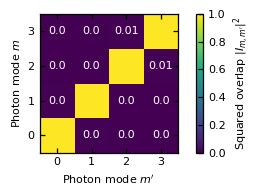

In [5]:
corrected_analyzer.plot_squaredI_matrix(4)
# plt.savefig("Fig2_c.pdf")
# plt.savefig("Fig3_b.png", bbox_inches='tight')
plt.show()

fogi pulse generation for absoption

Saved Recieve_Pulse for data_sech_0 at D:\K_Sunada\result\control_pulses\CDK183\
Saved Recieve_Pulse for data_sech_1 at D:\K_Sunada\result\control_pulses\CDK183\
Saved Recieve_Pulse for data_sech_2 at D:\K_Sunada\result\control_pulses\CDK183\
Saved Recieve_Pulse for data_sech_3 at D:\K_Sunada\result\control_pulses\CDK183\


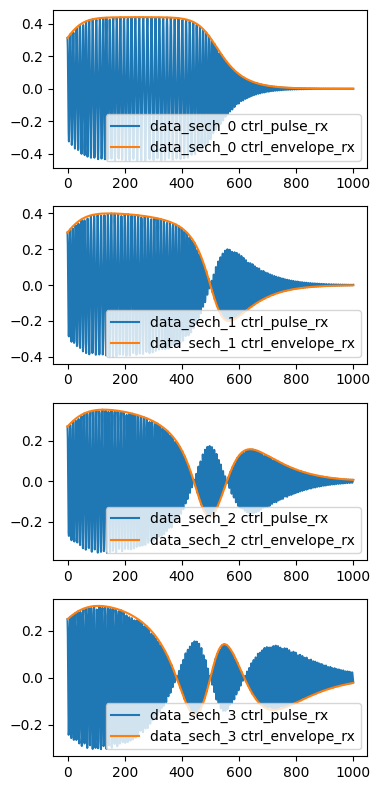

In [ ]:
corrected_analyzer.generate_control_pulse_rx(ctrl_pulse_path, save=False)